In [ ]:
pip install pyeit

Jumlah elemen mesh: 1326
Jumlah injeksi: 16
Jumlah elektroda: 16
Jumlah fitur X: 256
[Tumor] 1/500
[Tumor] 21/500
[Tumor] 41/500
[Tumor] 61/500
[Tumor] 81/500
[Tumor] 101/500
[Tumor] 121/500
[Tumor] 141/500
[Tumor] 161/500
[Tumor] 181/500
[Tumor] 201/500
[Tumor] 221/500
[Tumor] 241/500
[Tumor] 261/500
[Tumor] 281/500
[Tumor] 301/500
[Tumor] 321/500
[Tumor] 341/500
[Tumor] 361/500
[Tumor] 381/500
[Tumor] 401/500
[Tumor] 421/500
[Tumor] 441/500
[Tumor] 461/500
[Tumor] 481/500
[Pneumonia] 1/500
[Pneumonia] 21/500
[Pneumonia] 41/500
[Pneumonia] 61/500
[Pneumonia] 81/500
[Pneumonia] 101/500
[Pneumonia] 121/500
[Pneumonia] 141/500
[Pneumonia] 161/500
[Pneumonia] 181/500
[Pneumonia] 201/500
[Pneumonia] 221/500
[Pneumonia] 241/500
[Pneumonia] 261/500
[Pneumonia] 281/500
[Pneumonia] 301/500
[Pneumonia] 321/500
[Pneumonia] 341/500
[Pneumonia] 361/500
[Pneumonia] 381/500
[Pneumonia] 401/500
[Pneumonia] 421/500
[Pneumonia] 441/500
[Pneumonia] 461/500
[Pneumonia] 481/500
[Effusion] 1/500
[Effusion]

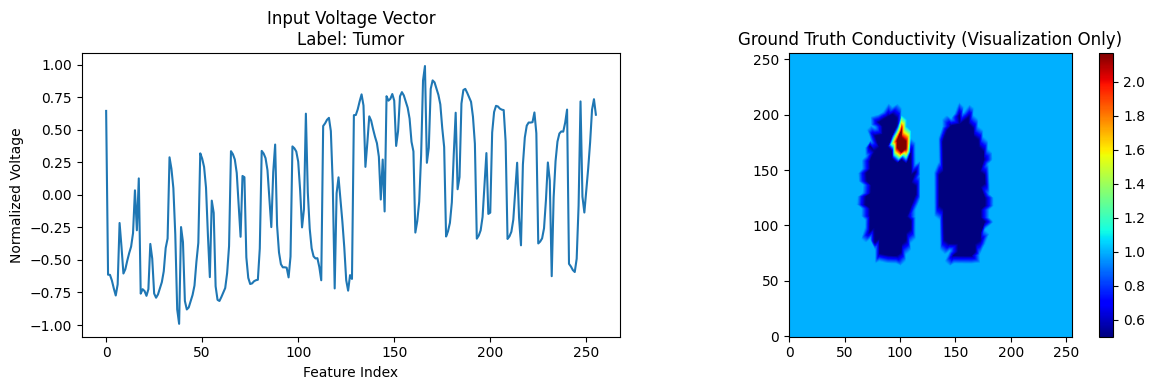

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward

# =========================================================
# 1. REPRODUCIBILITY
# =========================================================
np.random.seed(42)

# =========================================================
# 2. MESH THORAX
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]

n_elem = len(tri)
print("Jumlah elemen mesh:", n_elem)

# =========================================================
# 3. DEFINISI PARU
# =========================================================
lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

# =========================================================
# 4. PROTOCOL
# =========================================================
protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

ex_mat = protocol_obj.ex_mat
n_inj = len(ex_mat)
n_el = len(el_pos)

print("Jumlah injeksi:", n_inj)
print("Jumlah elektroda:", n_el)

# =========================================================
# 5. INPUT DIMENSION
# PAPER: 208 boundary voltage values
# Karena setup kamu 16x16, kita flatten:
# (n_inj, n_el) -> vector
# =========================================================
n_features = n_inj * n_el
print("Jumlah fitur X:", n_features)

# =========================================================
# 6. GRID UNTUK VISUALISASI SAJA
# =========================================================
nx_vis, ny_vis = 256, 256
gx_vis = np.linspace(pts[:, 0].min(), pts[:, 0].max(), nx_vis)
gy_vis = np.linspace(pts[:, 1].min(), pts[:, 1].max(), ny_vis)
GX_vis, GY_vis = np.meshgrid(gx_vis, gy_vis)

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

# =========================================================
# 7. PHANTOM FUNCTIONS
# =========================================================
def make_tumor_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.04, 0.09)
    ry = np.random.uniform(0.04, 0.09)
    sigma_tumor = np.random.uniform(2.0, 3.0)

    tumor = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    tumor = tumor & (lung_left if side == "left" else lung_right)

    perm[tumor] = sigma_tumor

    info = {
        "type": "tumor",
        "label": 0,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_tumor
    }
    return perm, info

def make_pneumonia_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.06, 0.12)
    ry = np.random.uniform(0.06, 0.12)
    sigma_lesion = np.random.uniform(1.25, 1.5)

    lesion = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    lesion = lesion & (lung_left if side == "left" else lung_right)

    perm[lesion] = sigma_lesion

    info = {
        "type": "pneumonia",
        "label": 1,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_lesion
    }
    return perm, info

def make_effusion_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        lung_mask = lung_left
        x0 = -0.25
    else:
        lung_mask = lung_right
        x0 = 0.25

    rx = np.random.uniform(0.14, 0.22)
    ry = np.random.uniform(0.10, 0.16)
    tx = x0 + np.random.uniform(-0.03, 0.03)
    ty = np.random.uniform(-0.28, -0.12)

    pocket_outer = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0

    rx_inner = rx * np.random.uniform(0.55, 0.75)
    ry_inner = ry * np.random.uniform(0.55, 0.75)
    tx_inner = tx + np.random.uniform(-0.01, 0.01)
    ty_inner = ty + np.random.uniform(0.03, 0.07)

    pocket_inner = (((cx - tx_inner) / rx_inner) ** 2 + ((cy - ty_inner) / ry_inner) ** 2) <= 1.0

    effusion = pocket_outer & (~pocket_inner)
    effusion = effusion & (cy < 0.02)
    effusion = effusion & (~lung_mask)

    sigma_effusion = 3.5
    perm[effusion] = sigma_effusion

    info = {
        "type": "pleural_effusion",
        "label": 2,
        "side": side,
        "center": (tx, ty),
        "radius_outer": (rx, ry),
        "sigma": sigma_effusion
    }
    return perm, info

# =========================================================
# 8. FORWARD SOLVER -> X VECTOR
# =========================================================
def solve_forward_vector(perm):
    mesh_obj.perm = perm

    try:
        fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
    except Exception:
        fwd = EITForward(mesh_obj, protocol_obj)

    x_sample = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_sample[j, :] = node_potential[el_pos].astype(np.float32)

    return x_sample.reshape(-1).astype(np.float32)   # flatten -> (n_features,)

# =========================================================
# 9. GENERATE DATASET 1500
# X: (1500, n_features)
# Y: (1500, n_elem)
# =========================================================
n_tumor = 500
n_pneumonia = 500
n_effusion = 500
n_total = n_tumor + n_pneumonia + n_effusion

X = np.zeros((n_total, n_features), dtype=np.float32)
Y = np.zeros((n_total, n_elem), dtype=np.float32)
labels = np.zeros((n_total,), dtype=np.int32)
info_list = []

idx = 0

for i in range(n_tumor):
    if i % 20 == 0:
        print(f"[Tumor] {i+1}/{n_tumor}")
    perm, info = make_tumor_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 0
    info_list.append(info)
    idx += 1

for i in range(n_pneumonia):
    if i % 20 == 0:
        print(f"[Pneumonia] {i+1}/{n_pneumonia}")
    perm, info = make_pneumonia_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 1
    info_list.append(info)
    idx += 1

for i in range(n_effusion):
    if i % 20 == 0:
        print(f"[Effusion] {i+1}/{n_effusion}")
    perm, info = make_effusion_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 2
    info_list.append(info)
    idx += 1

print("Dataset selesai dibuat.")
print("Shape X:", X.shape)
print("Shape Y:", Y.shape)
print("Shape labels:", labels.shape)

# =========================================================
# 10. SHUFFLE
# =========================================================
perm_idx = np.random.permutation(n_total)
X = X[perm_idx]
Y = Y[perm_idx]
labels = labels[perm_idx]
info_list = [info_list[i] for i in perm_idx]

# =========================================================
# 11. SPLIT TRAIN / VAL / TEST (70/15/15)
# =========================================================
X_train, X_temp, Y_train, Y_temp, labels_train, labels_temp = train_test_split(
    X, Y, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, Y_val, Y_test, labels_val, labels_test = train_test_split(
    X_temp, Y_temp, labels_temp,
    test_size=0.50,
    random_state=42,
    stratify=labels_temp
)

print("\n===== HASIL SPLIT =====")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

print("Train class:", np.bincount(labels_train))
print("Val class  :", np.bincount(labels_val))
print("Test class :", np.bincount(labels_test))

# =========================================================
# 12. NORMALIZE INPUT X SAJA
# PAPER pakai MSE dan training langsung pada conductivity target
# jadi Y dibiarkan di skala aslinya
# =========================================================
x_mean = X_train.mean(axis=0, keepdims=True)
x_std = X_train.std(axis=0, keepdims=True) + 1e-8

X_train_n = (X_train - x_mean) / x_std
X_val_n   = (X_val   - x_mean) / x_std
X_test_n  = (X_test  - x_mean) / x_std

print("\nInput normalization selesai.")

# =========================================================
# 13. SAVE DATASET
# =========================================================
np.savez_compressed(
    "eit_dataset_paper_style_1500.npz",
    X_train=X_train_n,
    Y_train=Y_train,
    labels_train=labels_train,
    X_val=X_val_n,
    Y_val=Y_val,
    labels_val=labels_val,
    X_test=X_test_n,
    Y_test=Y_test,
    labels_test=labels_test,
    x_mean=x_mean,
    x_std=x_std
)

print("Saved: eit_dataset_paper_style_1500.npz")

# =========================================================
# 14. VISUAL CHECK
# =========================================================
label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 0
perm_true = Y_train[sample_idx]
img_true = perm_to_grid(perm_true, GX_vis, GY_vis)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(X_train_n[sample_idx])
plt.title(f"Input Voltage Vector\nLabel: {label_names[int(labels_train[sample_idx])]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 2, 2)
plt.imshow(img_true, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity (Visualization Only)")
plt.colorbar()

plt.tight_layout()
plt.show()

Y_test shape     : (225, 1326)
labels_test shape: (225,)
Jumlah elemen mesh: 1326
shape v0: (192,)
Inverse progress: 20/225
Inverse progress: 40/225
Inverse progress: 60/225
Inverse progress: 80/225
Inverse progress: 100/225
Inverse progress: 120/225
Inverse progress: 140/225
Inverse progress: 160/225
Inverse progress: 180/225
Inverse progress: 200/225
Inverse progress: 220/225
Inverse progress: 225/225
Inverse reconstruction selesai.

===== HASIL GLOBAL JAC INVERSE =====
RMSE : 0.258232
R2   : -0.989229

===== HASIL PER KELAS =====
Tumor              -> RMSE: 0.199657 | R2: -0.032072
Pneumonia          -> RMSE: 0.193428 | R2: -0.394912
Pleural Effusion   -> RMSE: 0.350392 | R2: -0.027421


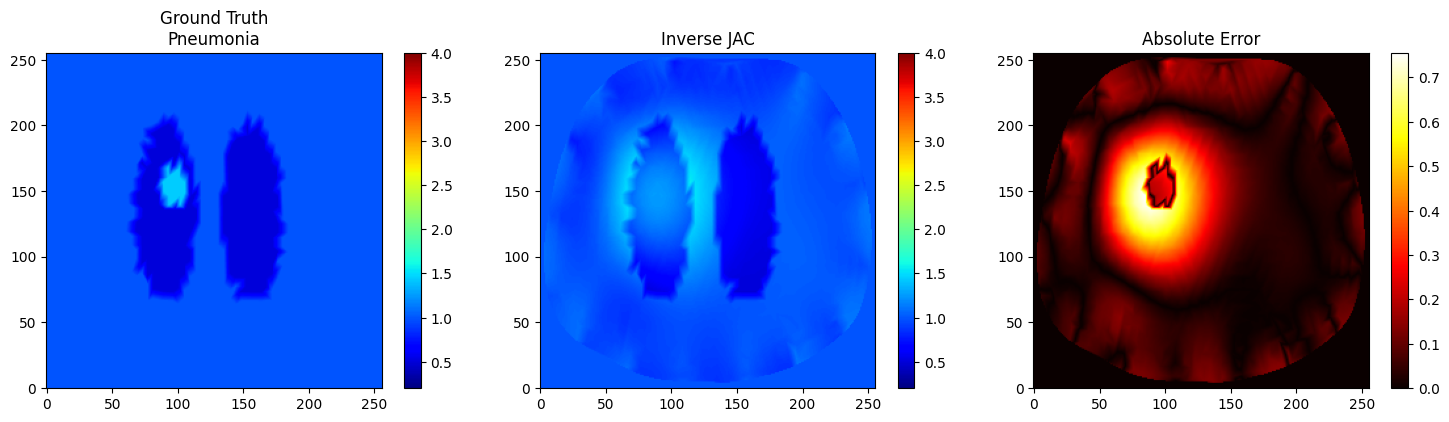

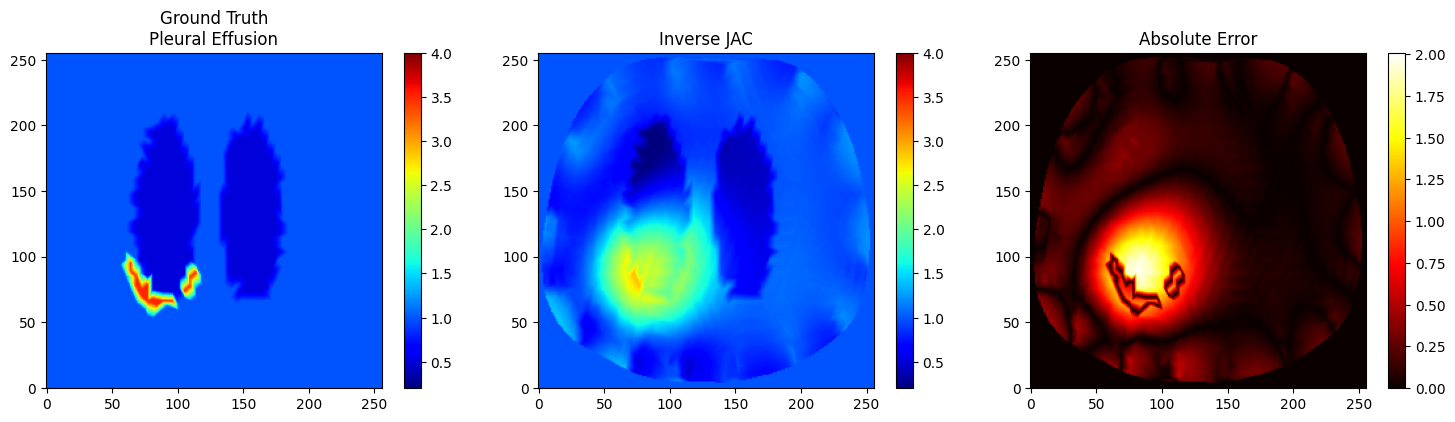

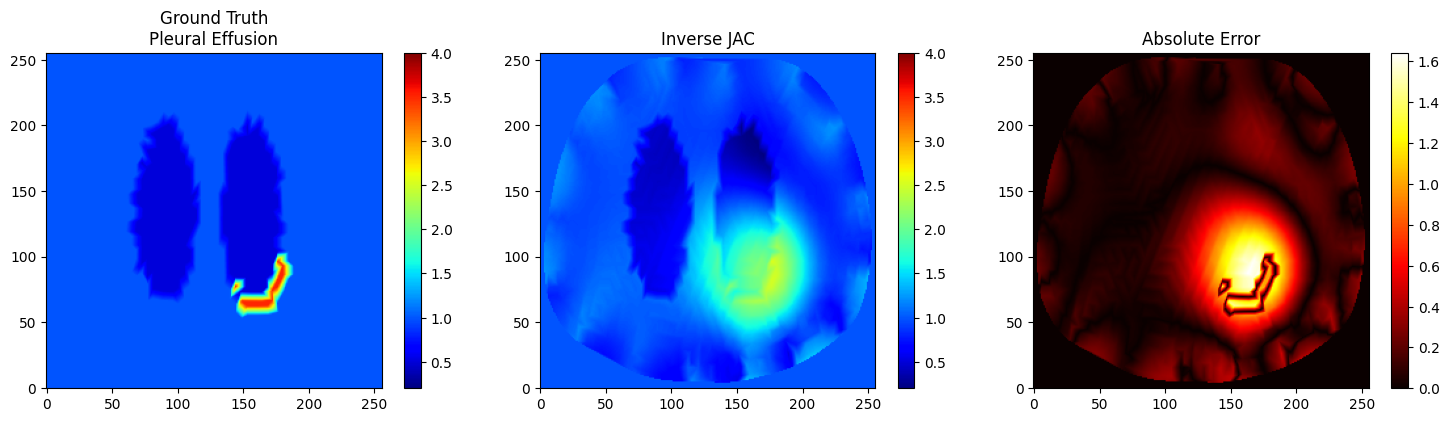

Saved: eit_inverse_jac_results.npz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward
from pyeit.eit.jac import JAC

# =========================================================
# 1) LOAD DATASET
# =========================================================
data = np.load("eit_dataset_paper_style_1500.npz", allow_pickle=True)

Y_test = data["Y_test"]
labels_test = data["labels_test"]

print("Y_test shape     :", Y_test.shape)
print("labels_test shape:", labels_test.shape)

# =========================================================
# 2) REBUILD MESH DAN PROTOCOL
# HARUS SAMA DENGAN SAAT DATASET DIBUAT
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]
n_elem = len(tri)

print("Jumlah elemen mesh:", n_elem)

lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

# =========================================================
# 3) BASELINE REFERENSI: THORAX SEHAT DENGAN PARU
# BUKAN HOMOGEN TOTAL
# =========================================================
perm_ref = np.ones(n_elem, dtype=np.float32)
perm_ref[lung_left] = 0.5
perm_ref[lung_right] = 0.5

# =========================================================
# 4) FORWARD SOLVER
# =========================================================
try:
    fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
except Exception:
    fwd = EITForward(mesh_obj, protocol_obj)

# baseline measurement
v0 = fwd.solve_eit(perm=perm_ref)
v0 = np.asarray(v0).reshape(-1)

print("shape v0:", v0.shape)

# =========================================================
# 5) INVERSE SOLVER: JAC
# =========================================================
eit = JAC(mesh_obj, protocol_obj)

# bisa dituning nanti
eit.setup(p=0.5, lamb=0.01, method="kotre")

# =========================================================
# 6) HELPER FUNCTIONS
# =========================================================
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def perm_to_grid(perm, gx=256, gy=256, fill_value=1.0):
    xg = np.linspace(pts[:, 0].min(), pts[:, 0].max(), gx)
    yg = np.linspace(pts[:, 1].min(), pts[:, 1].max(), gy)
    GX, GY = np.meshgrid(xg, yg)

    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), fill_value, img)
    return img

label_names = {
    0: "Tumor",
    1: "Pneumonia",
    2: "Pleural Effusion"
}

# =========================================================
# 7) LOOP SEMUA TEST SAMPLE
# - regenerate measurement v1 dari Y_test[i]
# - inverse dengan JAC
# - ubah hasil difference jadi conductivity estimate
# =========================================================
pred_inv = np.zeros_like(Y_test, dtype=np.float32)

for i in range(len(Y_test)):
    perm_true = Y_test[i].astype(np.float32)

    # generate measurement untuk phantom ini
    v1 = fwd.solve_eit(perm=perm_true)
    v1 = np.asarray(v1).reshape(-1)

    # difference reconstruction
    ds = eit.solve(v1, v0, normalize=True)
    ds = np.real(np.asarray(ds)).reshape(-1)

    # jadikan estimasi conductivity
    # asumsi sederhana: sigma_est = sigma_ref + delta_sigma
    perm_est = perm_ref + ds

    # batasi supaya tidak liar
    perm_est = np.clip(perm_est, 0.2, 4.0)

    pred_inv[i] = perm_est.astype(np.float32)

    if (i + 1) % 20 == 0 or (i + 1) == len(Y_test):
        print(f"Inverse progress: {i+1}/{len(Y_test)}")

print("Inverse reconstruction selesai.")

# =========================================================
# 8) EVALUASI GLOBAL
# =========================================================
rmse_all = compute_rmse(Y_test, pred_inv)
r2_all = r2_score(Y_test, pred_inv, multioutput="uniform_average")

print("\n===== HASIL GLOBAL JAC INVERSE =====")
print(f"RMSE : {rmse_all:.6f}")
print(f"R2   : {r2_all:.6f}")

# =========================================================
# 9) EVALUASI PER KELAS
# =========================================================
print("\n===== HASIL PER KELAS =====")
for label in [0, 1, 2]:
    idx = np.where(labels_test == label)[0]
    y_true_case = Y_test[idx]
    y_pred_case = pred_inv[idx]

    rmse_case = compute_rmse(y_true_case, y_pred_case)
    r2_case = r2_score(y_true_case, y_pred_case, multioutput="uniform_average")

    print(f"{label_names[label]:<18} -> RMSE: {rmse_case:.6f} | R2: {r2_case:.6f}")

# =========================================================
# 10) VISUAL CHECK BEBERAPA SAMPLE
# =========================================================
sample_indices = [0, 1, 2]

for sample_idx in sample_indices:
    true_perm = Y_test[sample_idx]
    pred_perm = pred_inv[sample_idx]

    true_img = perm_to_grid(true_perm, fill_value=1.0)
    pred_img = perm_to_grid(pred_perm, fill_value=1.0)
    err_img = np.abs(pred_img - true_img)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(true_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title(f"Ground Truth\n{label_names[int(labels_test[sample_idx])]}")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title("Inverse JAC")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(err_img, cmap="hot", origin="lower")
    plt.title("Absolute Error")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# =========================================================
# 11) OPTIONAL: SIMPAN HASIL
# =========================================================
np.savez_compressed(
    "eit_inverse_jac_results.npz",
    Y_test=Y_test,
    labels_test=labels_test,
    pred_inv=pred_inv,
    perm_ref=perm_ref,
    v0=v0
)

print("Saved: eit_inverse_jac_results.npz")

In [ ]:
# =========================================================
# 🔥 GENERATE & SAVE RAW DATASET (NO SHUFFLE, NO SPLIT)
# =========================================================

import numpy as np

np.random.seed(42)

n_tumor = 500
n_pneumonia = 500
n_effusion = 500
n_total = n_tumor + n_pneumonia + n_effusion

X_raw = np.zeros((n_total, n_features), dtype=np.float32)
Y_raw = np.zeros((n_total, n_elem), dtype=np.float32)
labels_raw = np.zeros((n_total,), dtype=np.int32)
info_list = []

idx = 0

# -------------------------------
# TUMOR (0–499)
# -------------------------------
for i in range(n_tumor):
    if i % 50 == 0:
        print(f"[Tumor] {i+1}/{n_tumor}")
    perm, info = make_tumor_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 0
    info_list.append(info)
    idx += 1

# -------------------------------
# PNEUMONIA (500–999)
# -------------------------------
for i in range(n_pneumonia):
    if i % 50 == 0:
        print(f"[Pneumonia] {i+1}/{n_pneumonia}")
    perm, info = make_pneumonia_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 1
    info_list.append(info)
    idx += 1

# -------------------------------
# EFFUSION (1000–1499)
# -------------------------------
for i in range(n_effusion):
    if i % 50 == 0:
        print(f"[Effusion] {i+1}/{n_effusion}")
    perm, info = make_effusion_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 2
    info_list.append(info)
    idx += 1

print("\nRAW dataset selesai dibuat!")
print("Shape X_raw:", X_raw.shape)
print("Shape Y_raw:", Y_raw.shape)
print("Shape labels_raw:", labels_raw.shape)

# =========================================================
# 🔥 SAVE RAW DATASET
# =========================================================
np.savez_compressed(
    "eit_dataset_raw_1500.npz",
    X_raw=X_raw,
    Y_raw=Y_raw,
    labels_raw=labels_raw,
    info_list=info_list
)

print("Saved: eit_dataset_raw_1500.npz")


[Tumor] 1/500
[Tumor] 51/500
[Tumor] 101/500
[Tumor] 151/500
[Tumor] 201/500
[Tumor] 251/500
[Tumor] 301/500
[Tumor] 351/500
[Tumor] 401/500
[Tumor] 451/500
[Pneumonia] 1/500
[Pneumonia] 51/500
[Pneumonia] 101/500
[Pneumonia] 151/500
[Pneumonia] 201/500
[Pneumonia] 251/500
[Pneumonia] 301/500
[Pneumonia] 351/500
[Pneumonia] 401/500
[Pneumonia] 451/500
[Effusion] 1/500
[Effusion] 51/500
[Effusion] 101/500
[Effusion] 151/500
[Effusion] 201/500
[Effusion] 251/500
[Effusion] 301/500
[Effusion] 351/500
[Effusion] 401/500
[Effusion] 451/500

RAW dataset selesai dibuat!
Shape X_raw: (1500, 256)
Shape Y_raw: (1500, 1326)
Shape labels_raw: (1500,)
Saved: eit_dataset_raw_1500.npz


In [ ]:
# =========================================================
# FORWARD HARUS SAMA DENGAN DATASET
# =========================================================
def solve_forward_vector(perm):
    mesh_obj.perm = perm

    x_sample = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_sample[j, :] = node_potential[el_pos]

    return x_sample.reshape(-1)
# =========================================================
# FORWARD HARUS SAMA DENGAN DATASET
# =========================================================
def solve_forward_vector(perm):
    mesh_obj.perm = perm

    x_sample = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_sample[j, :] = node_potential[el_pos]

    return x_sample.reshape(-1)


X_raw: (1500, 256)
Y_raw: (1500, 1326)
Class        : Pleural Effusion
Index        : 1006
Label (raw)  : 2
v1: (192,) v0: (192,)
v1 shape: (192,)
v0 shape: (192,)


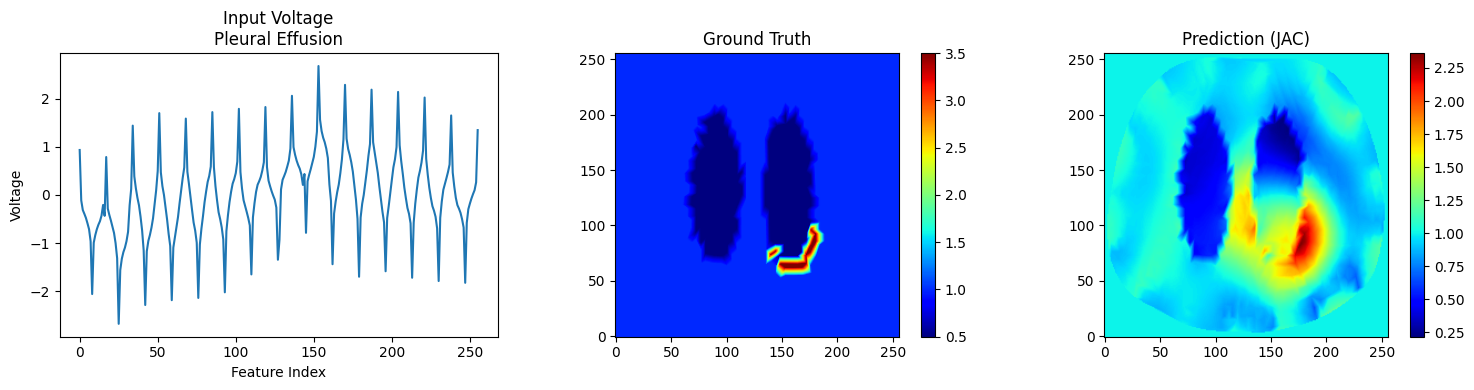

In [ ]:
# =========================================================
# 🔥 LOAD RAW DATASET
# =========================================================

data = np.load("eit_dataset_raw_1500.npz", allow_pickle=True)

X_raw = data["X_raw"]
Y_raw = data["Y_raw"]
labels_raw = data["labels_raw"]

print("X_raw:", X_raw.shape)
print("Y_raw:", Y_raw.shape)

# =========================================================
# 🔥 PILIH SAMPLE (FIXED INDEX)
# =========================================================

class_id = 2   # 0=tumor, 1=pneumonia, 2=effusion
n = 6        # data ke-(n+1)

index = class_id * 500 + n

print("===================================")
print("Class        :", label_names[class_id])
print("Index        :", index)
print("Label (raw)  :", labels_raw[index])
print("===================================")

# =========================================================
# 🔥 AMBIL DATA
# =========================================================

x_sample = X_raw[index]   # ini voltage hasil forward
y_true = Y_raw[index]

# =========================================================
# 🔥 INVERSE (JAC)
# =========================================================

# =========================================================
# 🔥 INVERSE (FIX YANG BENAR)
# =========================================================

# ❌ JANGAN:
# v1 = x_sample.reshape(-1)

# ✅ WAJIB:
v1 = fwd.solve_eit(perm=y_true)
v1 = np.asarray(v1).reshape(-1)

# sekarang pasti sama shape dengan v0
print("v1:", v1.shape, "v0:", v0.shape)

ds = eit.solve(v1, v0, normalize=True)
ds = np.real(np.asarray(ds)).reshape(-1)

y_pred = perm_ref + ds
y_pred = np.clip(y_pred, 0.2, 4.0)


# pastikan ukuran sama dengan v0
print("v1 shape:", v1.shape)
print("v0 shape:", v0.shape)

# 🔥 kalau mismatch, FIX:
if v1.shape != v0.shape:
    v1 = v1[:len(v0)]

ds = eit.solve(v1, v0, normalize=True)
ds = np.real(np.asarray(ds)).reshape(-1)

# reconstruct conductivity
y_pred = perm_ref + ds
y_pred = np.clip(y_pred, 0.2, 4.0)

# =========================================================
# 🔥 CONVERT KE IMAGE
# =========================================================

true_img = perm_to_grid(y_true, fill_value=1.0)
pred_img = perm_to_grid(y_pred, fill_value=1.0)

# =========================================================
# 🔥 PLOT (SAMA PERSIS KAYAK ML)
# =========================================================

plt.figure(figsize=(15,4))

# -------------------------------
# Input voltage (RAW)
# -------------------------------
plt.subplot(1,3,1)
plt.plot(x_sample)
plt.title(f"Input Voltage\n{label_names[class_id]}")
plt.xlabel("Feature Index")
plt.ylabel("Voltage")

# -------------------------------
# Ground truth
# -------------------------------
plt.subplot(1,3,2)
plt.imshow(true_img, cmap="jet", origin="lower")
#plt.imshow(pred_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)

plt.title("Ground Truth")
plt.colorbar()

# -------------------------------
# Prediction (JAC)
# -------------------------------
plt.subplot(1,3,3)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction (JAC)")
plt.colorbar()

plt.tight_layout()
plt.show()


# INVERSI vs ML

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.interpolate import griddata
import tensorflow as tf

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward
from pyeit.eit.jac import JAC

# =========================================================
# 1) LOAD DATASET
# =========================================================
data = np.load("eit_dataset_paper_style_1500.npz", allow_pickle=True)

X_train = data["X_train"]
Y_train = data["Y_train"]
labels_train = data["labels_train"]

X_val = data["X_val"]
Y_val = data["Y_val"]
labels_val = data["labels_val"]

X_test = data["X_test"]
Y_test = data["Y_test"]
labels_test = data["labels_test"]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val  :", X_val.shape)
print("Y_val  :", Y_val.shape)
print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)

# =========================================================
# 2) REBUILD MESH + PROTOCOL
# HARUS SAMA DENGAN GENERATOR DATASET
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]
n_elem = len(tri)

lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

print("Jumlah elemen mesh:", n_elem)
print("Jumlah excitation :", len(protocol_obj.ex_mat))

# =========================================================
# 3) BASELINE REFERENSI UNTUK INVERSE KLASIK
# THORAX SEHAT + PARU NORMAL (tanpa lesi)
# =========================================================
perm_ref = np.ones(n_elem, dtype=np.float32)
perm_ref[lung_left] = 0.5
perm_ref[lung_right] = 0.5

# =========================================================
# 4) FORWARD SOLVER DAN BASELINE v0
# =========================================================
try:
    fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
except Exception:
    fwd = EITForward(mesh_obj, protocol_obj)

v0 = fwd.solve_eit(perm=perm_ref)
v0 = np.asarray(v0).reshape(-1)

print("shape v0:", v0.shape)

# =========================================================
# 5) INVERSE SOLVER: JAC
# =========================================================
eit = JAC(mesh_obj, protocol_obj)
eit.setup(p=0.5, lamb=0.01, method="kotre")

# =========================================================
# 6) LOAD MODEL DEEP LEARNING
# =========================================================
model1 = tf.keras.models.load_model("best_model_1.keras", compile=False)
model2 = tf.keras.models.load_model("best_model_2.keras", compile=False)
model3 = tf.keras.models.load_model("best_model_3.keras", compile=False)

print("Semua model berhasil di-load.")

# =========================================================
# 7) HELPER FUNCTIONS
# =========================================================
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate_model(name, y_true, y_pred):
    rmse = compute_rmse(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")
    print(f"{name:<20} -> RMSE: {rmse:.6f} | R2: {r2:.6f}")
    return rmse, r2

def perm_to_grid(perm, gx=256, gy=256, fill_value=1.0):
    xg = np.linspace(pts[:, 0].min(), pts[:, 0].max(), gx)
    yg = np.linspace(pts[:, 1].min(), pts[:, 1].max(), gy)
    GX, GY = np.meshgrid(xg, yg)

    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), fill_value, img)
    return img

label_names = {
    0: "Tumor",
    1: "Pneumonia",
    2: "Pleural Effusion"
}

# =========================================================
# 8) PREDIKSI DL DI VAL DAN TEST
# =========================================================
pred1_val = model1.predict(X_val, batch_size=32, verbose=0)
pred2_val = model2.predict(X_val, batch_size=32, verbose=0)
pred3_val = model3.predict(X_val, batch_size=32, verbose=0)

pred1_test = model1.predict(X_test, batch_size=32, verbose=0)
pred2_test = model2.predict(X_test, batch_size=32, verbose=0)
pred3_test = model3.predict(X_test, batch_size=32, verbose=0)

# =========================================================
# 9) CARI BOBOT ENSEMBLE TERBAIK DARI VALIDATION SET
# sama seperti konsep kode Anda sebelumnya
# =========================================================
best_r2 = -np.inf
best_weights = None

weight_candidates = np.arange(0.0, 1.01, 0.1)

for w1 in weight_candidates:
    for w2 in weight_candidates:
        for w3 in weight_candidates:
            s = w1 + w2 + w3
            if s == 0:
                continue

            pred_val = (w1 * pred1_val + w2 * pred2_val + w3 * pred3_val) / s
            r2 = r2_score(Y_val, pred_val, multioutput="uniform_average")

            if r2 > best_r2:
                best_r2 = r2
                best_weights = (w1, w2, w3)

w1, w2, w3 = best_weights
s = w1 + w2 + w3

pred_dl_test = (w1 * pred1_test + w2 * pred2_test + w3 * pred3_test) / s

print("\n===== BEST ENSEMBLE =====")
print("Best weights:", best_weights)
print("Best validation R2:", best_r2)

# clipping biar tetap fisik
pred_dl_test = np.clip(pred_dl_test, 0.2, 4.0).astype(np.float32)

# =========================================================
# 10) INVERSE KLASIK JAC UNTUK SEMUA Y_test
# Opsi A: regenerate measurement dari Y_test
# =========================================================
pred_inv_test = np.zeros_like(Y_test, dtype=np.float32)

for i in range(len(Y_test)):
    perm_true = Y_test[i].astype(np.float32)

    # forward measurement untuk phantom ini
    v1 = fwd.solve_eit(perm=perm_true)
    v1 = np.asarray(v1).reshape(-1)

    # inverse difference
    ds = eit.solve(v1, v0, normalize=True)
    ds = np.real(np.asarray(ds)).reshape(-1)

    # pendekatan sederhana: conductivity_est = baseline + delta
    perm_est = perm_ref + ds
    perm_est = np.clip(perm_est, 0.2, 4.0)

    pred_inv_test[i] = perm_est.astype(np.float32)

    if (i + 1) % 20 == 0 or (i + 1) == len(Y_test):
        print(f"Inverse progress: {i+1}/{len(Y_test)}")

print("Inverse JAC selesai.")

# =========================================================
# 11) EVALUASI GLOBAL
# =========================================================
print("\n===== GLOBAL PERFORMANCE =====")
evaluate_model("Deep Learning Ensemble", Y_test, pred_dl_test)
evaluate_model("Classical Inverse JAC", Y_test, pred_inv_test)

# =========================================================
# 12) EVALUASI PER KELAS
# =========================================================
print("\n===== PER-CLASS PERFORMANCE =====")
for label in [0, 1, 2]:
    idx = np.where(labels_test == label)[0]

    y_true_case = Y_test[idx]
    y_dl_case = pred_dl_test[idx]
    y_inv_case = pred_inv_test[idx]

    print(f"\n--- {label_names[label]} ---")
    evaluate_model("DL Ensemble", y_true_case, y_dl_case)
    evaluate_model("Inverse JAC", y_true_case, y_inv_case)

# =========================================================
# 13) VISUALISASI PERBANDINGAN SAMPLE
# Ground Truth vs JAC vs DL
# =========================================================
sample_indices = [0, 1, 2, 3, 4]

for sample_idx in sample_indices:
    true_perm = Y_test[sample_idx]
    inv_perm = pred_inv_test[sample_idx]
    dl_perm = pred_dl_test[sample_idx]

    true_img = perm_to_grid(true_perm, fill_value=1.0)
    inv_img = perm_to_grid(inv_perm, fill_value=1.0)
    dl_img = perm_to_grid(dl_perm, fill_value=1.0)

    err_inv = np.abs(inv_img - true_img)
    err_dl = np.abs(dl_img - true_img)

    fig = plt.figure(figsize=(20, 7))

    plt.subplot(2, 3, 1)
    plt.imshow(true_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title(f"Ground Truth\n{label_names[int(labels_test[sample_idx])]}")
    plt.colorbar()

    plt.subplot(2, 3, 2)
    plt.imshow(inv_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title("Classical Inverse (JAC)")
    plt.colorbar()

    plt.subplot(2, 3, 3)
    plt.imshow(dl_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title("Deep Learning Ensemble")
    plt.colorbar()

    plt.subplot(2, 3, 5)
    plt.imshow(err_inv, cmap="hot", origin="lower")
    plt.title("Absolute Error - JAC")
    plt.colorbar()

    plt.subplot(2, 3, 6)
    plt.imshow(err_dl, cmap="hot", origin="lower")
    plt.title("Absolute Error - DL")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# =========================================================
# 14) SIMPAN HASIL
# =========================================================
np.savez_compressed(
    "comparison_jac_vs_dl.npz",
    Y_test=Y_test,
    labels_test=labels_test,
    pred_inv_test=pred_inv_test,
    pred_dl_test=pred_dl_test,
    best_weights=np.array(best_weights, dtype=np.float32),
    perm_ref=perm_ref,
    v0=v0
)

print("Saved: comparison_jac_vs_dl.npz")

# OPSI B

Jumlah elemen mesh: 1326
Jumlah injeksi: 16
Jumlah elektroda: 16
Jumlah fitur X_dl: 256
Jumlah fitur X_inv: 192
[Tumor] 1/500
[Tumor] 21/500
[Tumor] 41/500
[Tumor] 61/500
[Tumor] 81/500
[Tumor] 101/500
[Tumor] 121/500
[Tumor] 141/500
[Tumor] 161/500
[Tumor] 181/500
[Tumor] 201/500
[Tumor] 221/500
[Tumor] 241/500
[Tumor] 261/500
[Tumor] 281/500
[Tumor] 301/500
[Tumor] 321/500
[Tumor] 341/500
[Tumor] 361/500
[Tumor] 381/500
[Tumor] 401/500
[Tumor] 421/500
[Tumor] 441/500
[Tumor] 461/500
[Tumor] 481/500
[Pneumonia] 1/500
[Pneumonia] 21/500
[Pneumonia] 41/500
[Pneumonia] 61/500
[Pneumonia] 81/500
[Pneumonia] 101/500
[Pneumonia] 121/500
[Pneumonia] 141/500
[Pneumonia] 161/500
[Pneumonia] 181/500
[Pneumonia] 201/500
[Pneumonia] 221/500
[Pneumonia] 241/500
[Pneumonia] 261/500
[Pneumonia] 281/500
[Pneumonia] 301/500
[Pneumonia] 321/500
[Pneumonia] 341/500
[Pneumonia] 361/500
[Pneumonia] 381/500
[Pneumonia] 401/500
[Pneumonia] 421/500
[Pneumonia] 441/500
[Pneumonia] 461/500
[Pneumonia] 481/500


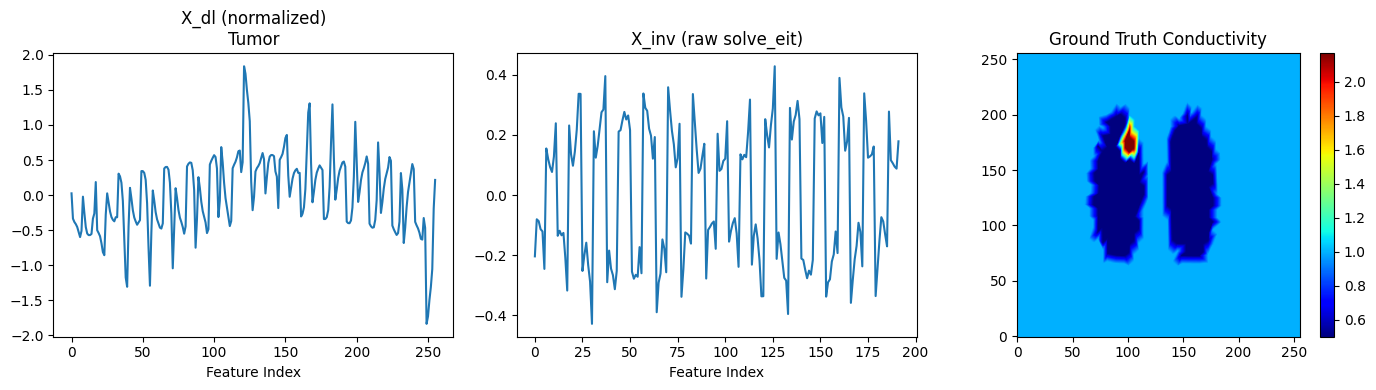

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward

# =========================================================
# 1. REPRODUCIBILITY
# =========================================================
np.random.seed(42)

# =========================================================
# 2. MESH THORAX
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]

n_elem = len(tri)
print("Jumlah elemen mesh:", n_elem)

# =========================================================
# 3. DEFINISI PARU
# =========================================================
lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

# =========================================================
# 4. PROTOCOL
# dist_exc=8 sesuai generator Anda
# =========================================================
protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

ex_mat = protocol_obj.ex_mat
n_inj = len(ex_mat)
n_el = len(el_pos)

print("Jumlah injeksi:", n_inj)
print("Jumlah elektroda:", n_el)

# =========================================================
# 5. DIMENSI INPUT
# X_dl  = node potential pada elektroda per excitation
# X_inv = measurement vector solve_eit()
# =========================================================
n_features_dl = n_inj * n_el
print("Jumlah fitur X_dl:", n_features_dl)

# cari dimensi X_inv dari baseline
perm_tmp = np.ones(n_elem, dtype=float)
perm_tmp[lung_left] = 0.5
perm_tmp[lung_right] = 0.5

try:
    fwd_tmp = EITForward(mesh_obj, protocol_obj, z=0.01)
except Exception:
    fwd_tmp = EITForward(mesh_obj, protocol_obj)

x_inv_tmp = np.asarray(fwd_tmp.solve_eit(perm=perm_tmp)).reshape(-1)
n_features_inv = len(x_inv_tmp)
print("Jumlah fitur X_inv:", n_features_inv)

# =========================================================
# 6. GRID UNTUK VISUALISASI
# =========================================================
nx_vis, ny_vis = 256, 256
gx_vis = np.linspace(pts[:, 0].min(), pts[:, 0].max(), nx_vis)
gy_vis = np.linspace(pts[:, 1].min(), pts[:, 1].max(), ny_vis)
GX_vis, GY_vis = np.meshgrid(gx_vis, gy_vis)

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

# =========================================================
# 7. PHANTOM FUNCTIONS
# =========================================================
def make_tumor_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.04, 0.09)
    ry = np.random.uniform(0.04, 0.09)
    sigma_tumor = np.random.uniform(2.0, 3.0)

    tumor = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    tumor = tumor & (lung_left if side == "left" else lung_right)

    perm[tumor] = sigma_tumor

    info = {
        "type": "tumor",
        "label": 0,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_tumor
    }
    return perm, info

def make_pneumonia_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.06, 0.12)
    ry = np.random.uniform(0.06, 0.12)
    sigma_lesion = np.random.uniform(1.25, 1.5)

    lesion = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    lesion = lesion & (lung_left if side == "left" else lung_right)

    perm[lesion] = sigma_lesion

    info = {
        "type": "pneumonia",
        "label": 1,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_lesion
    }
    return perm, info

def make_effusion_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        lung_mask = lung_left
        x0 = -0.25
    else:
        lung_mask = lung_right
        x0 = 0.25

    rx = np.random.uniform(0.14, 0.22)
    ry = np.random.uniform(0.10, 0.16)
    tx = x0 + np.random.uniform(-0.03, 0.03)
    ty = np.random.uniform(-0.28, -0.12)

    pocket_outer = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0

    rx_inner = rx * np.random.uniform(0.55, 0.75)
    ry_inner = ry * np.random.uniform(0.55, 0.75)
    tx_inner = tx + np.random.uniform(-0.01, 0.01)
    ty_inner = ty + np.random.uniform(0.03, 0.07)

    pocket_inner = (((cx - tx_inner) / rx_inner) ** 2 + ((cy - ty_inner) / ry_inner) ** 2) <= 1.0

    effusion = pocket_outer & (~pocket_inner)
    effusion = effusion & (cy < 0.02)
    effusion = effusion & (~lung_mask)

    sigma_effusion = 3.5
    perm[effusion] = sigma_effusion

    info = {
        "type": "pleural_effusion",
        "label": 2,
        "side": side,
        "center": (tx, ty),
        "radius_outer": (rx, ry),
        "sigma": sigma_effusion
    }
    return perm, info

# =========================================================
# 8. FORWARD SOLVER
# =========================================================
def get_forward_solver():
    try:
        return EITForward(mesh_obj, protocol_obj, z=0.01)
    except Exception:
        return EITForward(mesh_obj, protocol_obj)

def solve_forward_dual_input(perm):
    fwd = get_forward_solver()
    mesh_obj.perm = perm

    # -------------------------
    # X_dl: node potentials @ electrodes
    # -------------------------
    x_dl = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_dl[j, :] = node_potential[el_pos].astype(np.float32)

    x_dl = x_dl.reshape(-1).astype(np.float32)

    # -------------------------
    # X_inv: measurement vector solve_eit()
    # -------------------------
    x_inv = fwd.solve_eit(perm=perm)
    x_inv = np.asarray(x_inv).reshape(-1).astype(np.float32)

    return x_dl, x_inv

# =========================================================
# 9. GENERATE DATASET
# =========================================================
n_tumor = 500
n_pneumonia = 500
n_effusion = 500
n_total = n_tumor + n_pneumonia + n_effusion

X_dl = np.zeros((n_total, n_features_dl), dtype=np.float32)
X_inv = np.zeros((n_total, n_features_inv), dtype=np.float32)
Y = np.zeros((n_total, n_elem), dtype=np.float32)
labels = np.zeros((n_total,), dtype=np.int32)
info_list = []

idx = 0

for i in range(n_tumor):
    if i % 20 == 0:
        print(f"[Tumor] {i+1}/{n_tumor}")
    perm, info = make_tumor_phantom()
    x_dl, x_inv = solve_forward_dual_input(perm)
    X_dl[idx] = x_dl
    X_inv[idx] = x_inv
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 0
    info_list.append(info)
    idx += 1

for i in range(n_pneumonia):
    if i % 20 == 0:
        print(f"[Pneumonia] {i+1}/{n_pneumonia}")
    perm, info = make_pneumonia_phantom()
    x_dl, x_inv = solve_forward_dual_input(perm)
    X_dl[idx] = x_dl
    X_inv[idx] = x_inv
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 1
    info_list.append(info)
    idx += 1

for i in range(n_effusion):
    if i % 20 == 0:
        print(f"[Effusion] {i+1}/{n_effusion}")
    perm, info = make_effusion_phantom()
    x_dl, x_inv = solve_forward_dual_input(perm)
    X_dl[idx] = x_dl
    X_inv[idx] = x_inv
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 2
    info_list.append(info)
    idx += 1

print("Dataset selesai dibuat.")
print("Shape X_dl:", X_dl.shape)
print("Shape X_inv:", X_inv.shape)
print("Shape Y:", Y.shape)
print("Shape labels:", labels.shape)

# =========================================================
# 10. SHUFFLE
# =========================================================
perm_idx = np.random.permutation(n_total)
X_dl = X_dl[perm_idx]
X_inv = X_inv[perm_idx]
Y = Y[perm_idx]
labels = labels[perm_idx]
info_list = [info_list[i] for i in perm_idx]

# =========================================================
# 11. SPLIT TRAIN / VAL / TEST
# =========================================================
(
    X_dl_train, X_dl_temp,
    X_inv_train, X_inv_temp,
    Y_train, Y_temp,
    labels_train, labels_temp
) = train_test_split(
    X_dl, X_inv, Y, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

(
    X_dl_val, X_dl_test,
    X_inv_val, X_inv_test,
    Y_val, Y_test,
    labels_val, labels_test
) = train_test_split(
    X_dl_temp, X_inv_temp, Y_temp, labels_temp,
    test_size=0.50,
    random_state=42,
    stratify=labels_temp
)

print("\n===== HASIL SPLIT =====")
print("X_dl_train :", X_dl_train.shape)
print("X_inv_train:", X_inv_train.shape)
print("Y_train    :", Y_train.shape)

print("X_dl_val   :", X_dl_val.shape)
print("X_inv_val  :", X_inv_val.shape)
print("Y_val      :", Y_val.shape)

print("X_dl_test  :", X_dl_test.shape)
print("X_inv_test :", X_inv_test.shape)
print("Y_test     :", Y_test.shape)

print("Train class:", np.bincount(labels_train))
print("Val class  :", np.bincount(labels_val))
print("Test class :", np.bincount(labels_test))

# =========================================================
# 12. NORMALISASI
# DL biasanya dinormalisasi
# inverse klasik TIDAK perlu pakai hasil normalisasi ini
# =========================================================
x_dl_mean = X_dl_train.mean(axis=0, keepdims=True)
x_dl_std = X_dl_train.std(axis=0, keepdims=True) + 1e-8

X_dl_train_n = (X_dl_train - x_dl_mean) / x_dl_std
X_dl_val_n   = (X_dl_val   - x_dl_mean) / x_dl_std
X_dl_test_n  = (X_dl_test  - x_dl_mean) / x_dl_std

print("\nNormalisasi X_dl selesai.")
print("X_inv dibiarkan raw untuk inverse klasik.")

# =========================================================
# 13. SAVE DATASET
# =========================================================
np.savez_compressed(
    "eit_dataset_dual_input_1500.npz",
    X_dl_train=X_dl_train_n,
    X_dl_val=X_dl_val_n,
    X_dl_test=X_dl_test_n,

    X_inv_train=X_inv_train,
    X_inv_val=X_inv_val,
    X_inv_test=X_inv_test,

    Y_train=Y_train,
    Y_val=Y_val,
    Y_test=Y_test,

    labels_train=labels_train,
    labels_val=labels_val,
    labels_test=labels_test,

    x_dl_mean=x_dl_mean,
    x_dl_std=x_dl_std
)

print("Saved: eit_dataset_dual_input_1500.npz")

# =========================================================
# 14. VISUAL CHECK
# =========================================================
label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 0
perm_true = Y_train[sample_idx]
img_true = perm_to_grid(perm_true, GX_vis, GY_vis)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(X_dl_train_n[sample_idx])
plt.title(f"X_dl (normalized)\n{label_names[int(labels_train[sample_idx])]}")
plt.xlabel("Feature Index")

plt.subplot(1, 3, 2)
plt.plot(X_inv_train[sample_idx])
plt.title("X_inv (raw solve_eit)")
plt.xlabel("Feature Index")

plt.subplot(1, 3, 3)
plt.imshow(img_true, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity")
plt.colorbar()

plt.tight_layout()
plt.show()

X_dl_train : (1050, 256)
X_inv_test : (225, 192)
Y_train    : (1050, 1326)
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.3043 - mae: 0.4053
Epoch 1: val_loss improved from None to 0.04169, saving model to dual_best_model_1.keras

Epoch 1: finished saving model to dual_best_model_1.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.1419 - mae: 0.2406 - val_loss: 0.0417 - val_mae: 0.1101 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0424 - mae: 0.1121
Epoch 2: val_loss improved from 0.04169 to 0.03411, saving model to dual_best_model_1.keras

Epoch 2: finished saving model to dual_best_model_1.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0413 - mae: 0.1082 - val_loss: 0.0341 - val_mae: 0.0847 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0342 - mae: 0.0815
Epoch 3: val_loss improved from 0.03411 to 0.03031, saving model to dual_best_model_1.keras

Epoch 3: finished saving mod


===== DEEP LEARNING ENSEMBLE =====
Best weights: (np.float64(0.1), np.float64(0.6000000000000001), np.float64(0.2))
DL Ensemble            -> RMSE: 0.165510 | R2: 0.004270
shape baseline v0: (192,)
shape X_inv_test sample: (192,)
Inverse progress: 20/225
Inverse progress: 40/225
Inverse progress: 60/225
Inverse progress: 80/225
Inverse progress: 100/225
Inverse progress: 120/225
Inverse progress: 140/225
Inverse progress: 160/225
Inverse progress: 180/225
Inverse progress: 200/225
Inverse progress: 220/225
Inverse progress: 225/225

===== CLASSICAL INVERSE =====
Inverse JAC            -> RMSE: 0.258232 | R2: -0.989229

===== PER-CLASS PERFORMANCE =====

--- Tumor ---
DL Ensemble            -> RMSE: 0.155354 | R2: -0.001906
Inverse JAC            -> RMSE: 0.199657 | R2: -0.032072

--- Pneumonia ---
DL Ensemble            -> RMSE: 0.088881 | R2: -0.003783
Inverse JAC            -> RMSE: 0.193428 | R2: -0.394912

--- Pleural Effusion ---
DL Ensemble            -> RMSE: 0.223932 | R2: -0.

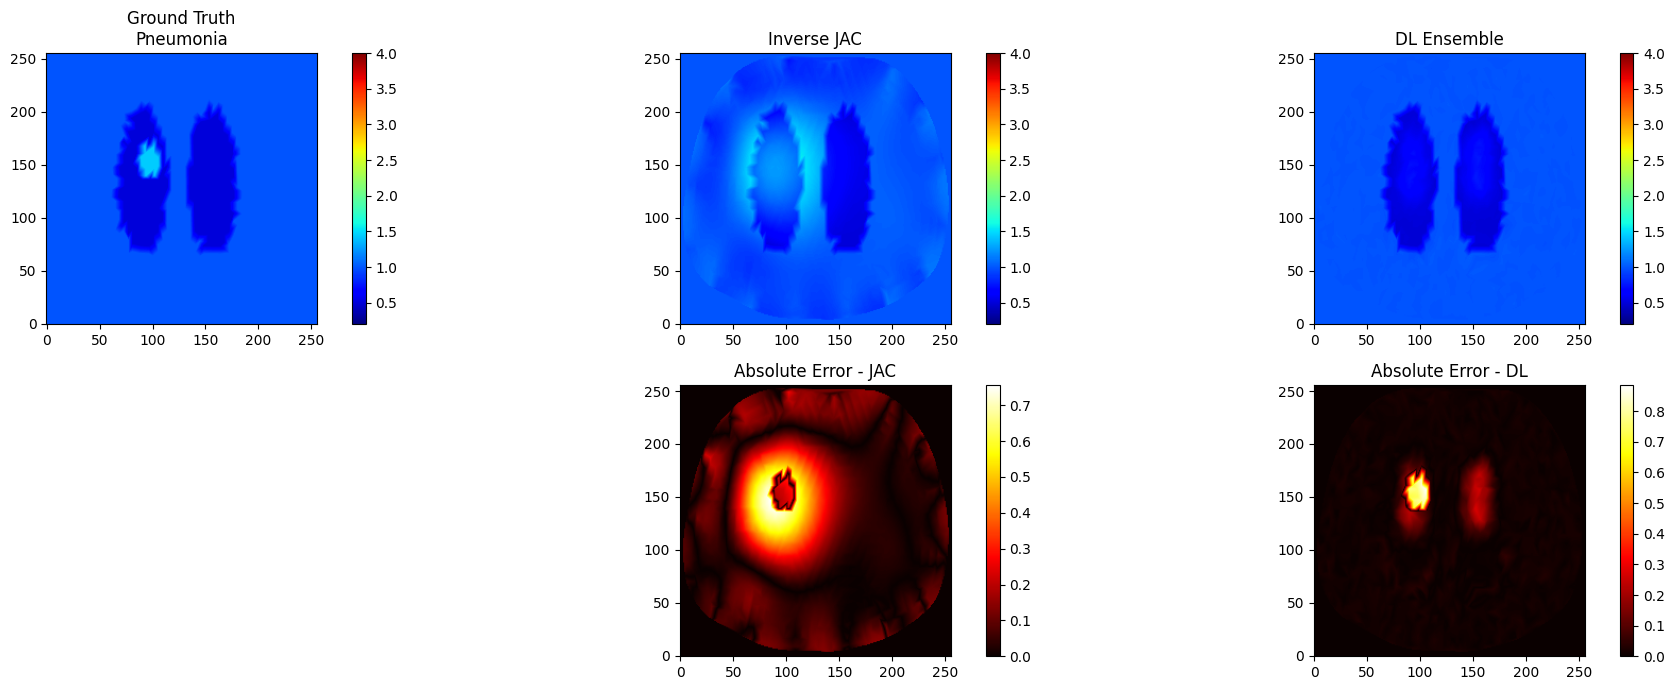

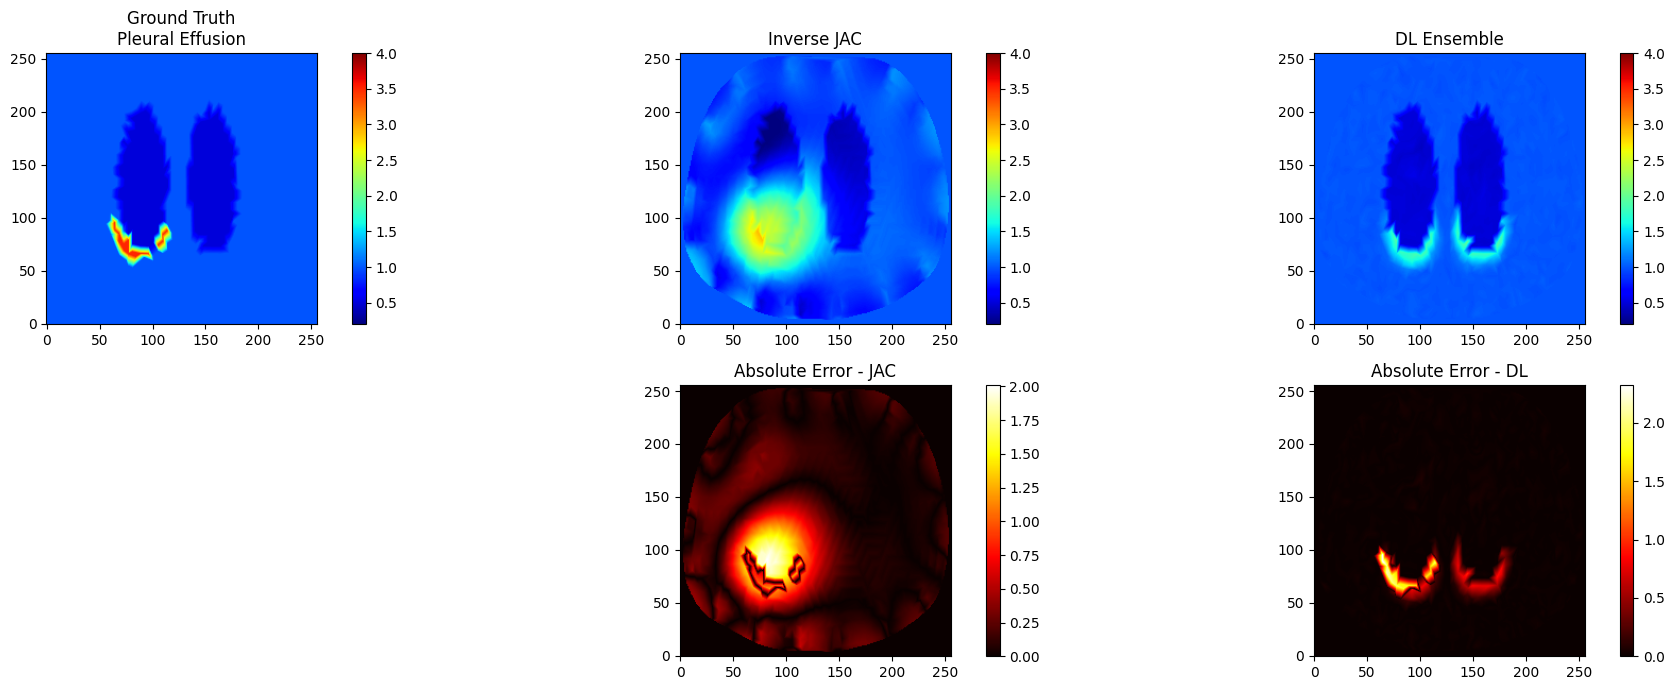

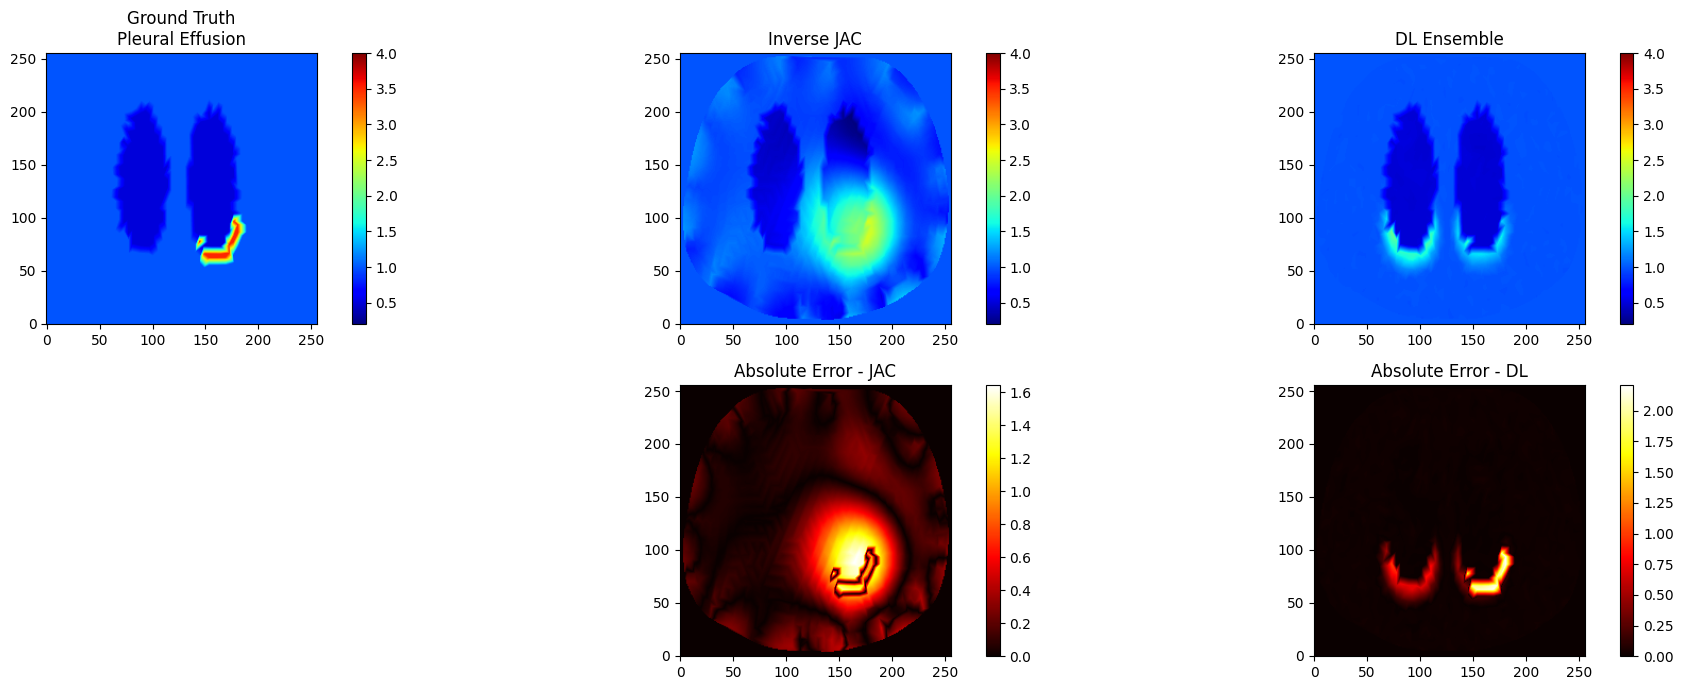

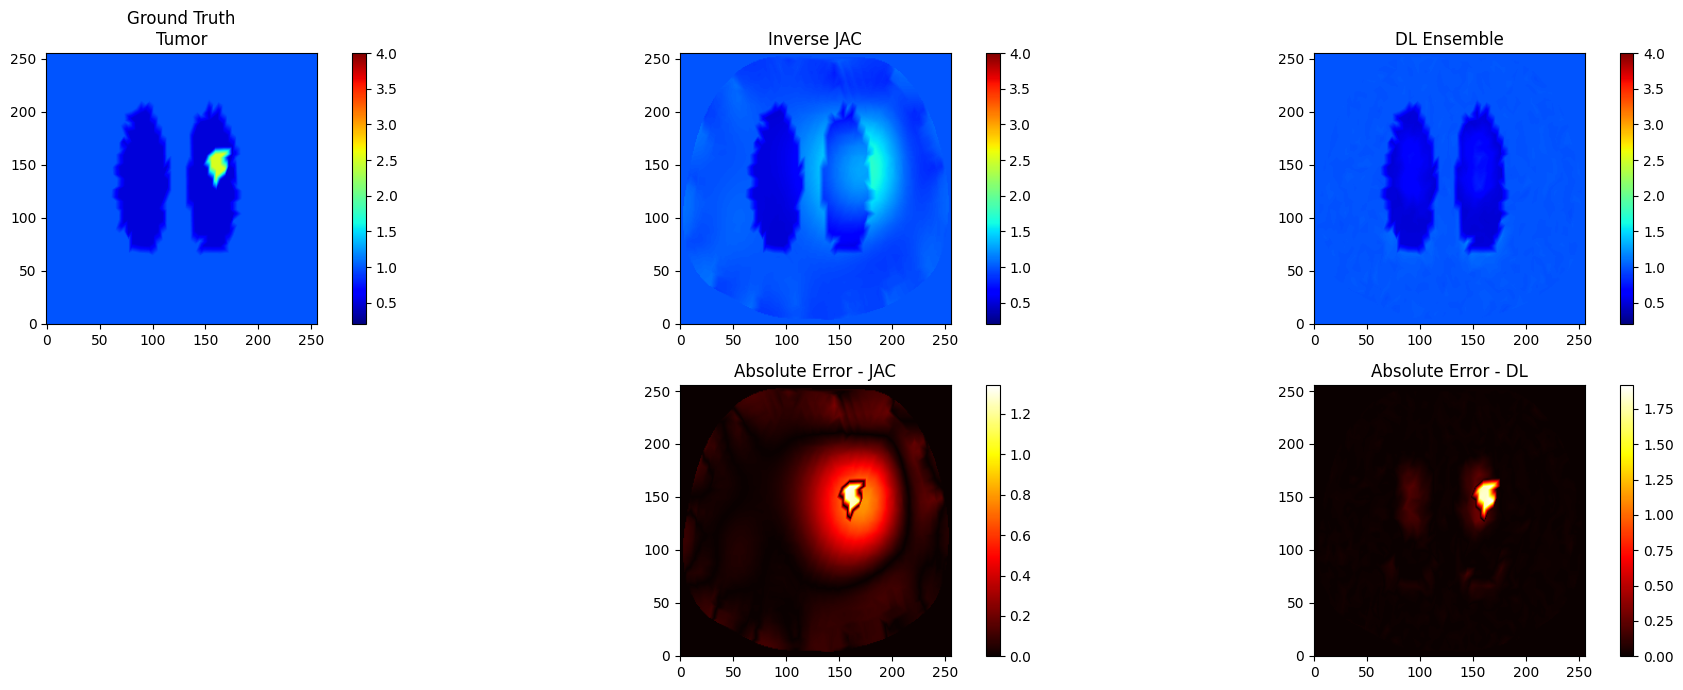

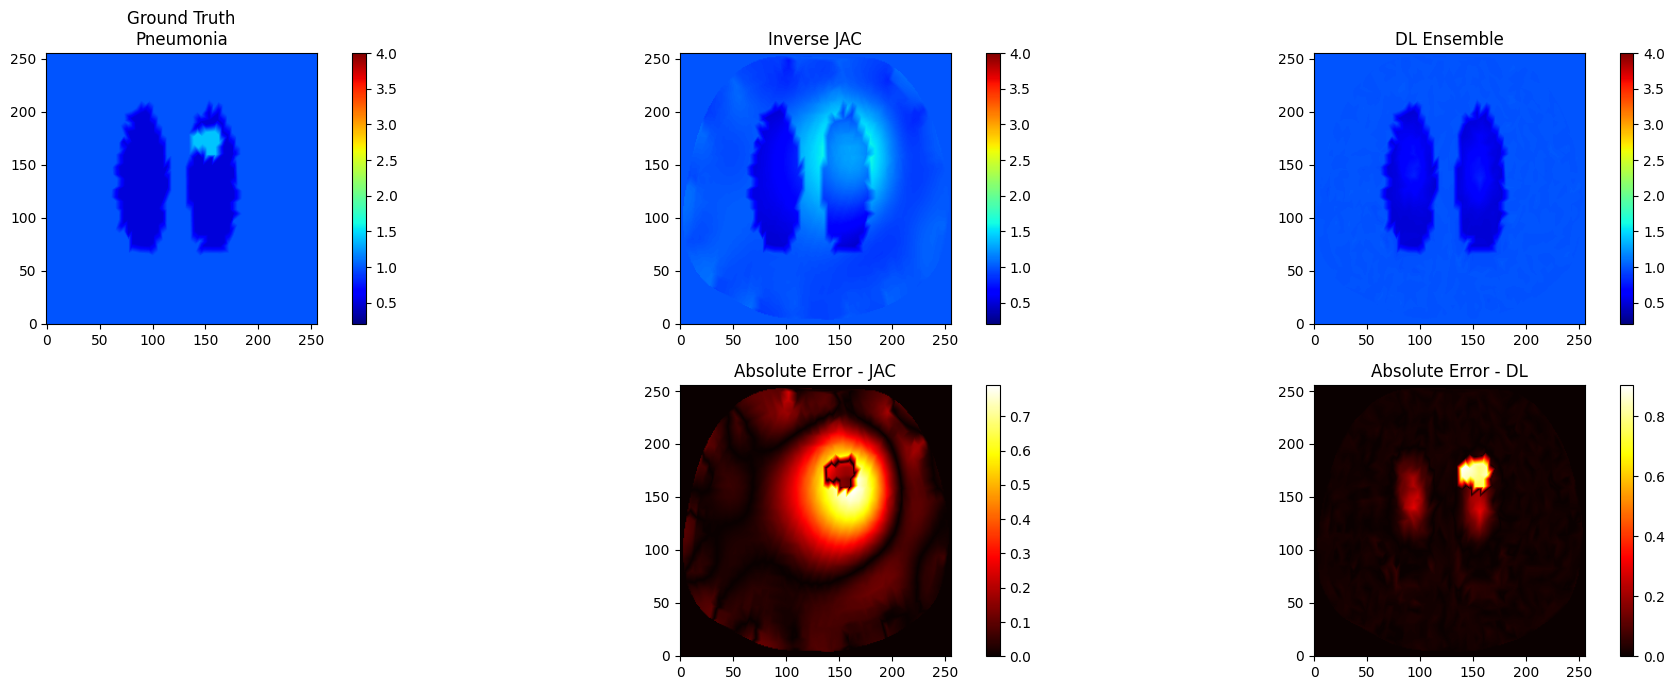

Saved: comparison_dual_input_jac_vs_dl.npz


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward
from pyeit.eit.jac import JAC

# =========================================================
# 1. LOAD DATASET
# =========================================================
data = np.load("eit_dataset_dual_input_1500.npz", allow_pickle=True)

X_dl_train = data["X_dl_train"]
X_dl_val   = data["X_dl_val"]
X_dl_test  = data["X_dl_test"]

X_inv_train = data["X_inv_train"]
X_inv_val   = data["X_inv_val"]
X_inv_test  = data["X_inv_test"]

Y_train = data["Y_train"]
Y_val   = data["Y_val"]
Y_test  = data["Y_test"]

labels_train = data["labels_train"]
labels_val   = data["labels_val"]
labels_test  = data["labels_test"]

print("X_dl_train :", X_dl_train.shape)
print("X_inv_test :", X_inv_test.shape)
print("Y_train    :", Y_train.shape)

input_dim = X_dl_train.shape[1]
output_dim = Y_train.shape[1]

# =========================================================
# 2. METRICS
# =========================================================
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate_model(name, y_true, y_pred):
    rmse = compute_rmse(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")
    print(f"{name:<22} -> RMSE: {rmse:.6f} | R2: {r2:.6f}")
    return rmse, r2

# =========================================================
# 3. MODEL DEFINITIONS
# =========================================================
def build_model_1():
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(512, activation="relu")(inputs)
    x = tf.keras.layers.Dense(1024, activation="relu")(x)
    x = tf.keras.layers.Dense(2048, activation="relu")(x)
    outputs = tf.keras.layers.Dense(output_dim, activation="linear")(x)
    return tf.keras.Model(inputs, outputs, name="model_1_simple")

def build_model_2():
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(512, activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(1024, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(2048, activation="relu")(x)
    outputs = tf.keras.layers.Dense(output_dim, activation="linear")(x)
    return tf.keras.Model(inputs, outputs, name="model_2_bn_dropout")

def build_model_3():
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(1024, activation="relu")(inputs)
    x1 = tf.keras.layers.Dense(1024, activation="relu")(x)
    x2 = tf.keras.layers.Dense(1024, activation="relu")(x1)
    x = tf.keras.layers.Add()([x1, x2])
    x = tf.keras.layers.Dense(2048, activation="relu")(x)
    outputs = tf.keras.layers.Dense(output_dim, activation="linear")(x)
    return tf.keras.Model(inputs, outputs, name="model_3_residual_like")

# =========================================================
# 4. TRAIN FUNCTION
# =========================================================
def train_one_model(model, save_name, epochs=100, batch_size=32):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            save_name,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        X_dl_train, Y_train,
        validation_data=(X_dl_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history

# =========================================================
# 5. TRAIN MODELS
# =========================================================
model1 = build_model_1()
history1 = train_one_model(model1, "dual_best_model_1.keras")

model2 = build_model_2()
history2 = train_one_model(model2, "dual_best_model_2.keras")

model3 = build_model_3()
history3 = train_one_model(model3, "dual_best_model_3.keras")

# =========================================================
# 6. PREDICT DL
# =========================================================
pred1_val = model1.predict(X_dl_val, batch_size=32, verbose=0)
pred2_val = model2.predict(X_dl_val, batch_size=32, verbose=0)
pred3_val = model3.predict(X_dl_val, batch_size=32, verbose=0)

pred1_test = model1.predict(X_dl_test, batch_size=32, verbose=0)
pred2_test = model2.predict(X_dl_test, batch_size=32, verbose=0)
pred3_test = model3.predict(X_dl_test, batch_size=32, verbose=0)

# =========================================================
# 7. WEIGHTED ENSEMBLE SEARCH
# =========================================================
best_r2 = -np.inf
best_weights = None

weight_candidates = np.arange(0.0, 1.01, 0.1)

for w1 in weight_candidates:
    for w2 in weight_candidates:
        for w3 in weight_candidates:
            s = w1 + w2 + w3
            if s == 0:
                continue

            pred_val = (w1 * pred1_val + w2 * pred2_val + w3 * pred3_val) / s
            r2 = r2_score(Y_val, pred_val, multioutput="uniform_average")

            if r2 > best_r2:
                best_r2 = r2
                best_weights = (w1, w2, w3)

w1, w2, w3 = best_weights
s = w1 + w2 + w3

pred_dl_test = (w1 * pred1_test + w2 * pred2_test + w3 * pred3_test) / s
pred_dl_test = np.clip(pred_dl_test, 0.2, 4.0)

print("\n===== DEEP LEARNING ENSEMBLE =====")
print("Best weights:", best_weights)
evaluate_model("DL Ensemble", Y_test, pred_dl_test)

# =========================================================
# 8. REBUILD MESH + PROTOCOL UNTUK INVERSE
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]

lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

# baseline sehat untuk inverse
perm_ref = np.ones(len(tri), dtype=np.float32)
perm_ref[lung_left] = 0.5
perm_ref[lung_right] = 0.5

try:
    fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
except Exception:
    fwd = EITForward(mesh_obj, protocol_obj)

v0 = fwd.solve_eit(perm=perm_ref)
v0 = np.asarray(v0).reshape(-1)

print("shape baseline v0:", v0.shape)
print("shape X_inv_test sample:", X_inv_test[0].shape)

# =========================================================
# 9. INVERSE KLASIK DARI X_inv_test
# =========================================================
eit = JAC(mesh_obj, protocol_obj)
eit.setup(p=0.5, lamb=0.01, method="kotre")

pred_inv_test = np.zeros_like(Y_test, dtype=np.float32)

for i in range(len(X_inv_test)):
    v1 = np.asarray(X_inv_test[i]).reshape(-1)

    ds = eit.solve(v1, v0, normalize=True)
    ds = np.real(np.asarray(ds)).reshape(-1)

    perm_est = perm_ref + ds
    perm_est = np.clip(perm_est, 0.2, 4.0)

    pred_inv_test[i] = perm_est.astype(np.float32)

    if (i + 1) % 20 == 0 or (i + 1) == len(X_inv_test):
        print(f"Inverse progress: {i+1}/{len(X_inv_test)}")

print("\n===== CLASSICAL INVERSE =====")
evaluate_model("Inverse JAC", Y_test, pred_inv_test)

# =========================================================
# 10. PER-CLASS EVALUATION
# =========================================================
label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

print("\n===== PER-CLASS PERFORMANCE =====")
for label in [0, 1, 2]:
    idx = np.where(labels_test == label)[0]

    print(f"\n--- {label_names[label]} ---")
    evaluate_model("DL Ensemble", Y_test[idx], pred_dl_test[idx])
    evaluate_model("Inverse JAC", Y_test[idx], pred_inv_test[idx])

# =========================================================
# 11. VISUALISASI
# =========================================================
def perm_to_grid(perm, gx=256, gy=256, fill_value=1.0):
    xg = np.linspace(pts[:, 0].min(), pts[:, 0].max(), gx)
    yg = np.linspace(pts[:, 1].min(), pts[:, 1].max(), gy)
    GX, GY = np.meshgrid(xg, yg)

    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), fill_value, img)
    return img

sample_indices = [0, 1, 2, 3, 4]

for sample_idx in sample_indices:
    true_img = perm_to_grid(Y_test[sample_idx])
    inv_img = perm_to_grid(pred_inv_test[sample_idx])
    dl_img = perm_to_grid(pred_dl_test[sample_idx])

    err_inv = np.abs(inv_img - true_img)
    err_dl = np.abs(dl_img - true_img)

    plt.figure(figsize=(20, 7))

    plt.subplot(2, 3, 1)
    plt.imshow(true_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title(f"Ground Truth\n{label_names[int(labels_test[sample_idx])]}")
    plt.colorbar()

    plt.subplot(2, 3, 2)
    plt.imshow(inv_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title("Inverse JAC")
    plt.colorbar()

    plt.subplot(2, 3, 3)
    plt.imshow(dl_img, cmap="jet", origin="lower", vmin=0.2, vmax=4.0)
    plt.title("DL Ensemble")
    plt.colorbar()

    plt.subplot(2, 3, 5)
    plt.imshow(err_inv, cmap="hot", origin="lower")
    plt.title("Absolute Error - JAC")
    plt.colorbar()

    plt.subplot(2, 3, 6)
    plt.imshow(err_dl, cmap="hot", origin="lower")
    plt.title("Absolute Error - DL")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# =========================================================
# 12. SAVE HASIL
# =========================================================
np.savez_compressed(
    "comparison_dual_input_jac_vs_dl.npz",
    Y_test=Y_test,
    labels_test=labels_test,
    pred_dl_test=pred_dl_test,
    pred_inv_test=pred_inv_test,
    best_weights=np.array(best_weights, dtype=np.float32),
    v0=v0,
    perm_ref=perm_ref
)

print("Saved: comparison_dual_input_jac_vs_dl.npz")
